# Tests using networkx and the status game

Jan 2025

In [1]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mesa

# Set a seed
np.random.seed(666)

# Plotting settings

from helpers import plot_all_agent_graphs
# Graphs font
plt.rcParams['font.family'] = 'Georgia'
color_dict = {
    'Anti - environment': 'orange',
    'Neutral': 'blue',
    'Pro - environment': 'green'
}


In [2]:
# Model with status and identity: Classical
from model_statusgame import statusgame_model
classical_game = statusgame_model(N = 1500, seed=666, lambda_s = 1, status_strategy = "nontie", memory = 15, type_game="classical")

os.chdir("/Users/santiagoherreragarcia/Documents/GitHub/uniandes/enviromental_behavior_dynamics/runs")

# Run the model
for it in range(60):
    if it%10 == 0: 
        print(it)
    classical_game = statusgame_model(N = 1500, seed=666, lambda_s = 1, status_strategy = "nontie", memory = 15, type_game="classical")
    
    for i in range(300):
        classical_game.step()

    # Collect data
    classical_game_model = classical_game.datacollector.get_model_vars_dataframe() 
    classical_game_agents = classical_game.datacollector.get_agent_vars_dataframe().reset_index()
    classical_game_agents.to_csv(f"classical_game_agents_{it}.csv")

0
10
20
30
40
50


In [3]:
# Model with status and identity: Alternative
os.chdir("/Users/santiagoherreragarcia/Documents/GitHub/uniandes/enviromental_behavior_dynamics/runs")
from model_statusgame import statusgame_model


# Run the model
for it in range(60):
    if it%10 == 0: 
        print(it)
    alternative_game = statusgame_model(N = 1500, seed=666, lambda_s = 1, status_strategy = "nontie", memory = 15, type_game="alternative")
    for i in range(300):
        alternative_game.step()

    # Collect data
    alternative_game_model = alternative_game.datacollector.get_model_vars_dataframe() 
    alternative_game_agents = alternative_game.datacollector.get_agent_vars_dataframe().reset_index()

    alternative_game_agents.to_csv(f"alternative_game_agents_{it}.csv")
    alternative_game_model.to_csv(f"alternative_game_model_{it}.csv")


0
10
20
30
40
50


Plot the initial version of the models

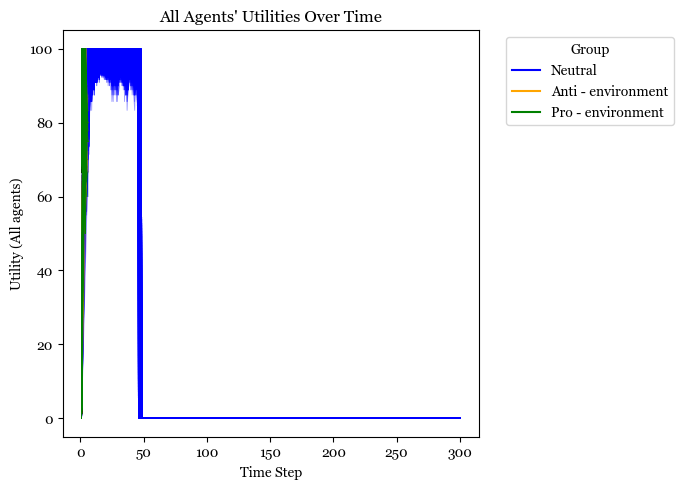

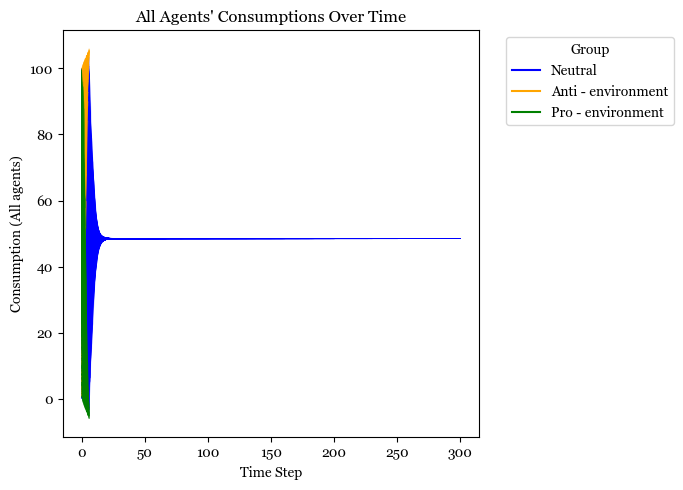

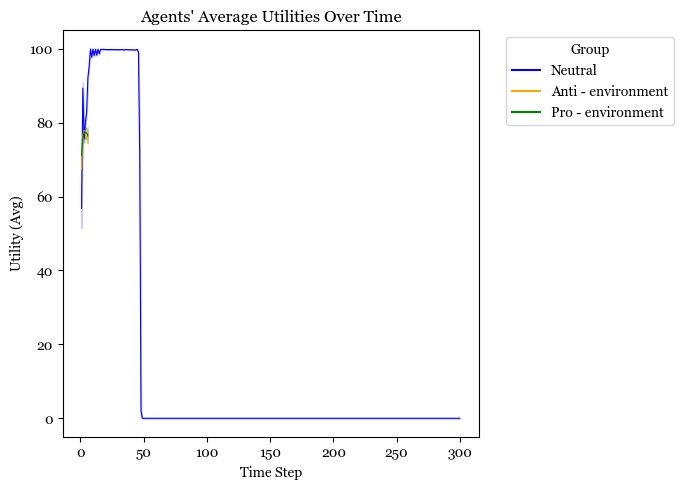

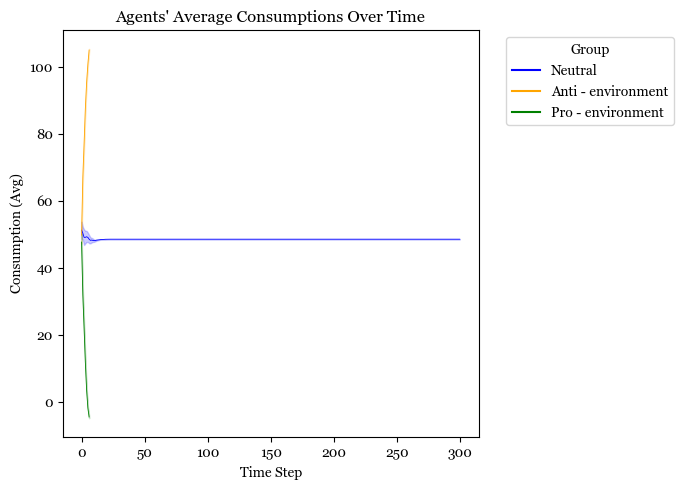

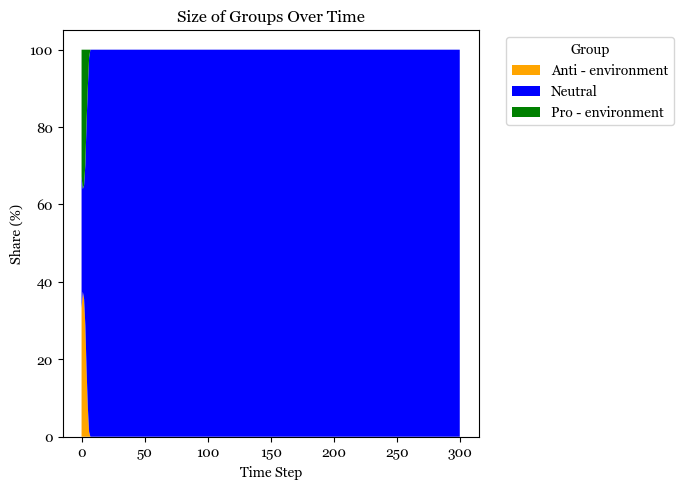

In [5]:
# Classical
os.chdir("/Users/santiagoherreragarcia/Documents/GitHub/uniandes/enviromental_behavior_dynamics/plots")
plot_all_agent_graphs(classical_game_agents, color_dict, output_folder="lambda_1_classical", show_plots=True)

In [ ]:
-1 
1 

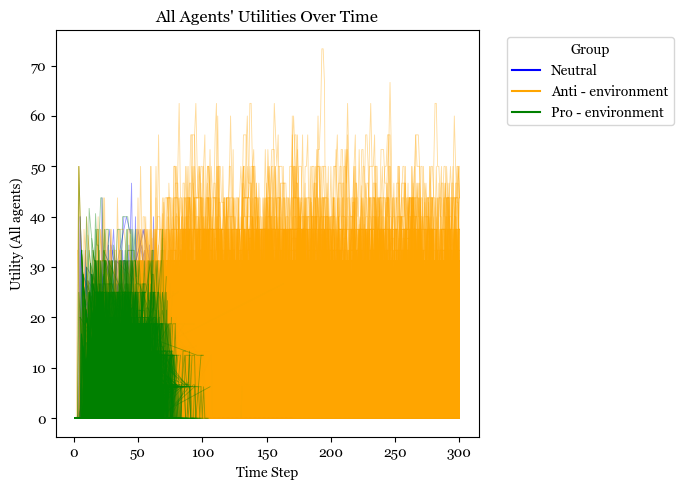

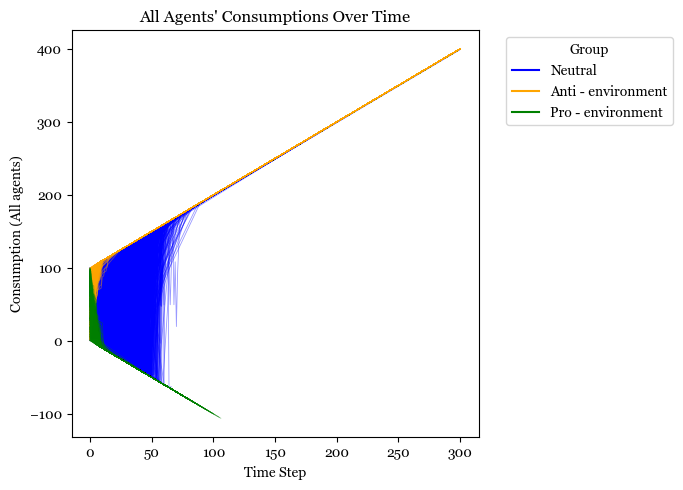

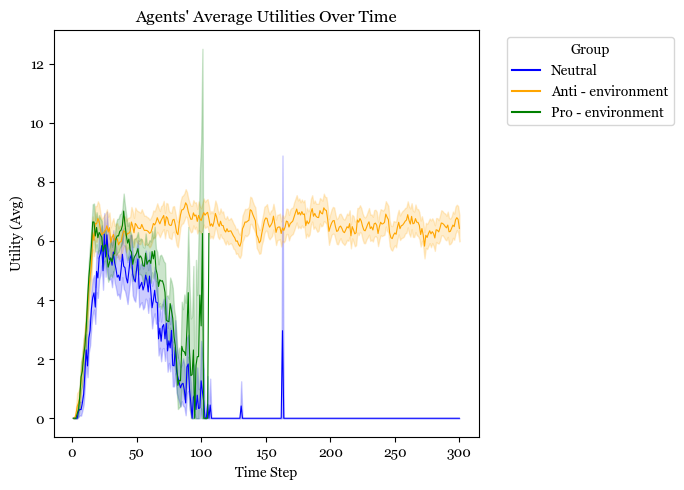

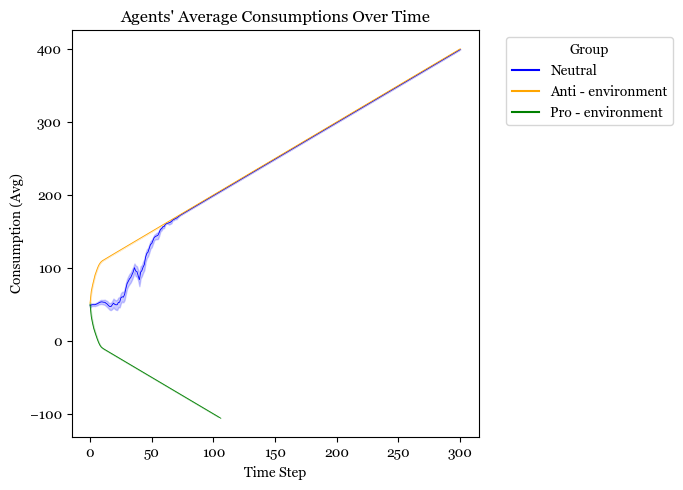

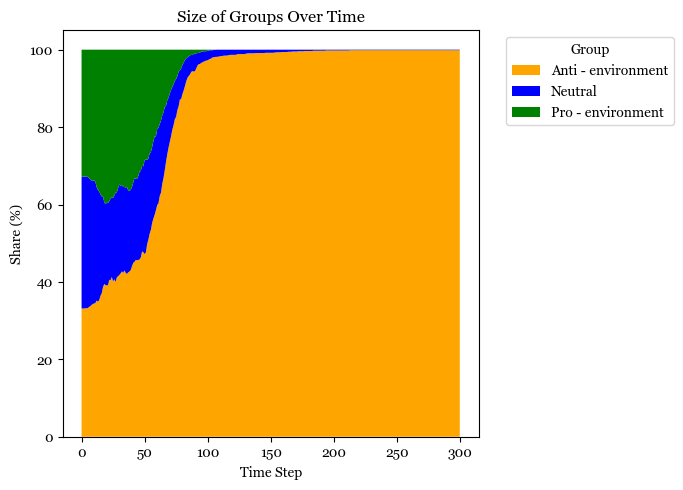

In [6]:
# Alternative
plot_all_agent_graphs(alternative_game_agents, color_dict, output_folder="lambda_1_alternative", show_plots=True)

In [14]:
## Leer las 60 bases
import os 
import pandas as pd
os.chdir("/Users/santiagoherreragarcia/Documents/GitHub/uniandes/enviromental_behavior_dynamics/runs")
counts = []
for c in range(60):
    alternative_game_agents = pd.read_csv(f"alternative_game_agents_{c}.csv")
    antis = alternative_game_agents.loc[alternative_game_agents["Step"] == 299, "group"].to_list().count("Neutral") / 1500
    counts.append(antis)
    

In [15]:
counts

[0.0006666666666666666,
 0.002,
 0.0006666666666666666,
 0.0,
 0.002,
 0.0013333333333333333,
 0.0006666666666666666,
 0.002,
 0.0006666666666666666,
 0.0026666666666666666,
 0.0006666666666666666,
 0.0013333333333333333,
 0.0,
 0.002,
 0.0,
 0.0013333333333333333,
 0.0013333333333333333,
 0.0006666666666666666,
 0.0,
 0.0006666666666666666,
 0.0,
 0.0013333333333333333,
 0.0026666666666666666,
 0.0013333333333333333,
 0.0013333333333333333,
 0.0013333333333333333,
 0.0,
 0.0006666666666666666,
 0.0,
 0.0006666666666666666,
 0.0013333333333333333,
 0.0006666666666666666,
 0.0013333333333333333,
 0.0013333333333333333,
 0.0006666666666666666,
 0.004,
 0.002,
 0.0013333333333333333,
 0.0013333333333333333,
 0.0006666666666666666,
 0.002,
 0.002,
 0.0013333333333333333,
 0.0,
 0.0006666666666666666,
 0.0013333333333333333,
 0.0,
 0.0013333333333333333,
 0.0006666666666666666,
 0.0026666666666666666,
 0.0006666666666666666,
 0.0013333333333333333,
 0.0026666666666666666,
 0.001333333333333

In [13]:
pd.Series(counts).value_counts()

0.000000    30
0.998667    12
0.999333     7
0.998000     6
1.000000     2
0.997333     2
0.996000     1
dtype: int64

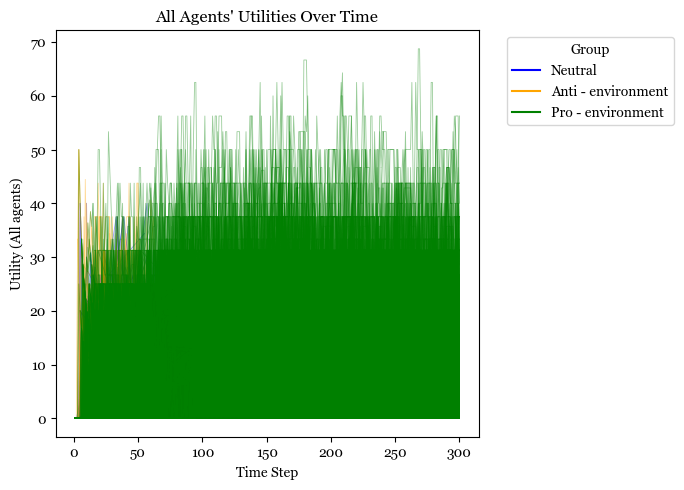

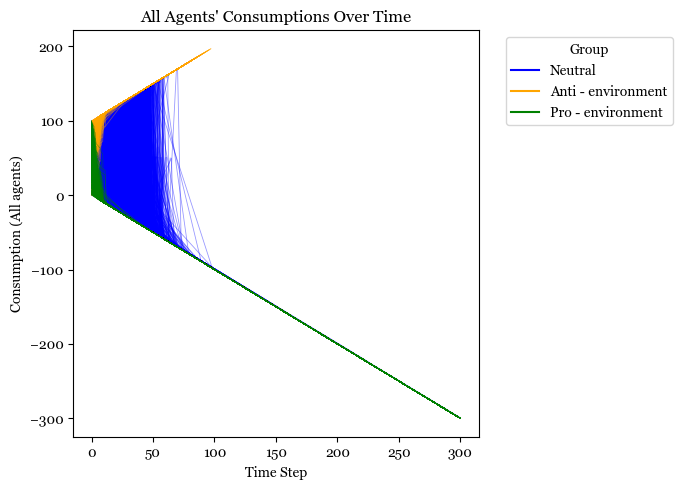

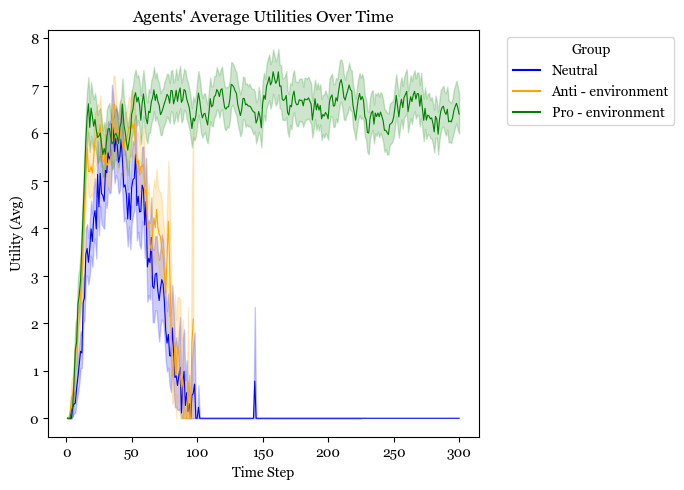

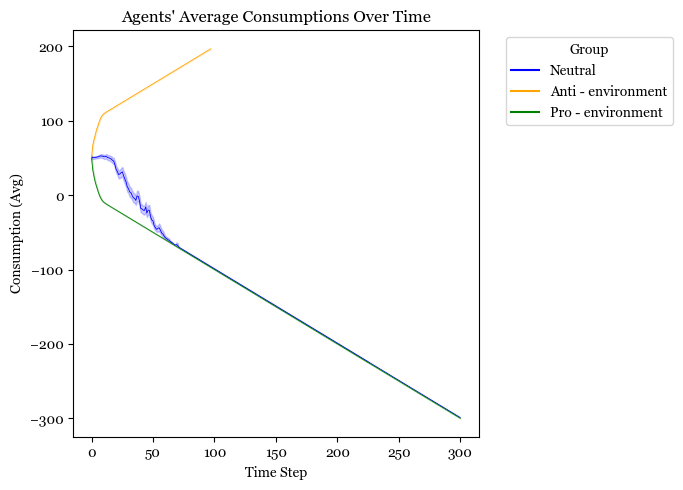

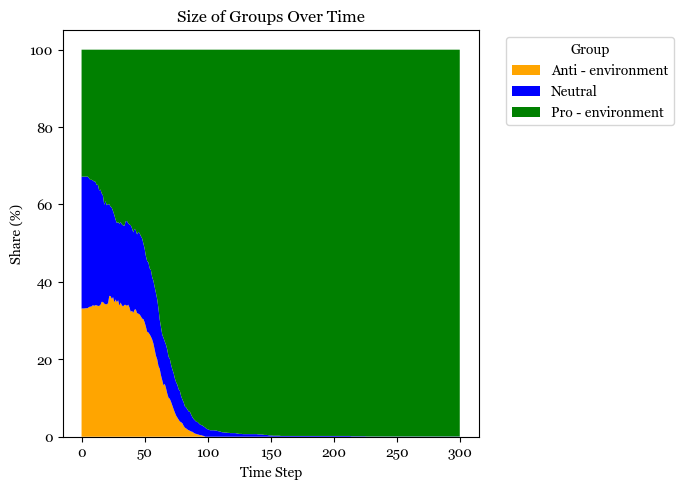

In [11]:
# Un contraejemplo
os.chdir("/Users/santiagoherreragarcia/Documents/GitHub/uniandes/enviromental_behavior_dynamics/runs")
alternative_game_agents = pd.read_csv("alternative_game_agents_2.csv")
plot_all_agent_graphs(alternative_game_agents, color_dict, output_folder="lambda_1_alternative_pros", show_plots=True)

In [2]:
# Test correctness of results
# Alternative
from model_statusgame import statusgame_model
alternative_game = statusgame_model(N = 1500, seed=666, lambda_s = 1, status_strategy = "nontie", memory = 15, type_game="alternative")
for i in range(300):
    alternative_game.step()
alternative_game_agents = alternative_game.datacollector.get_agent_vars_dataframe().reset_index()


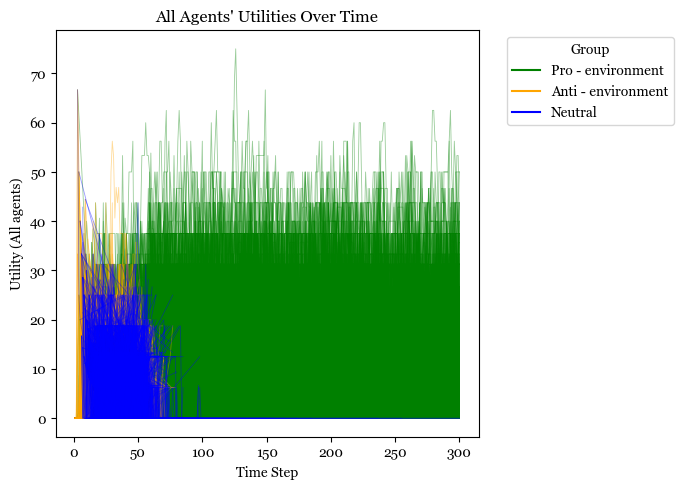

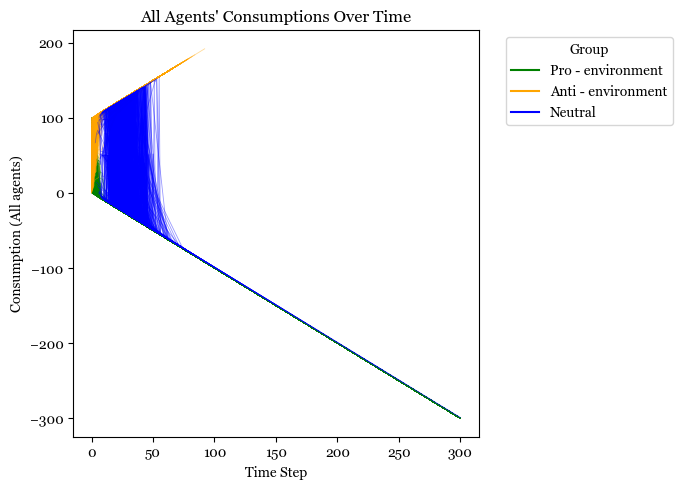

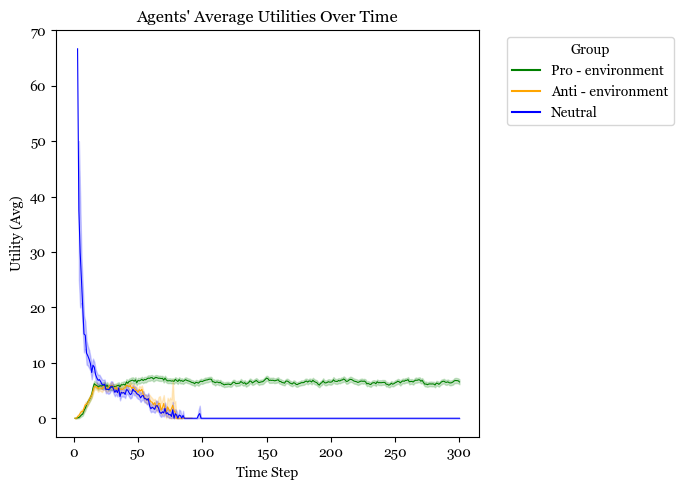

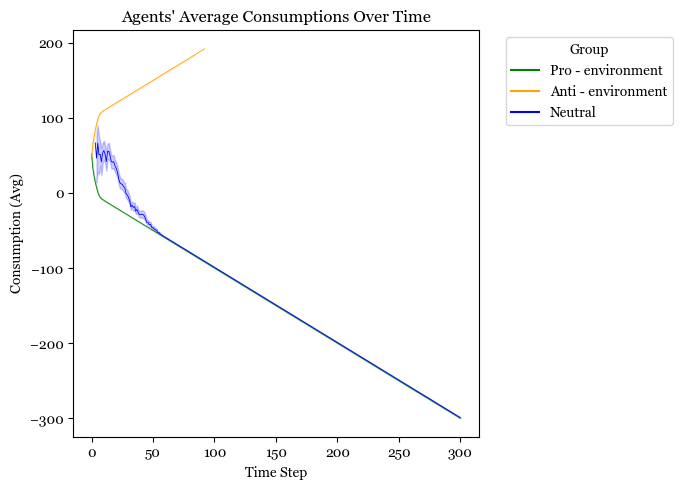

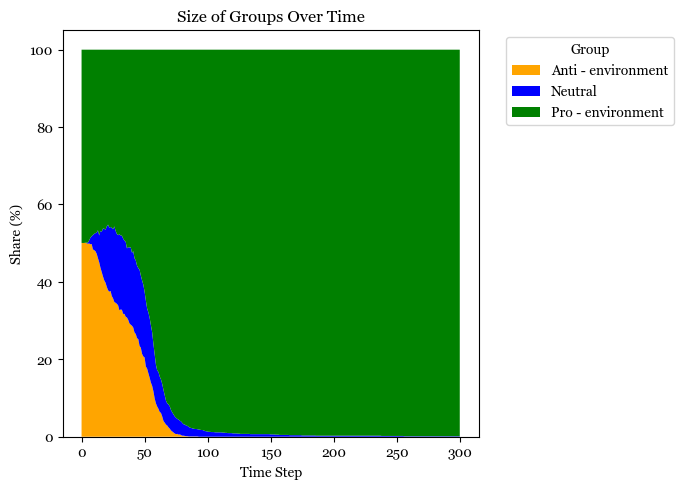

In [3]:
plot_all_agent_graphs(alternative_game_agents, color_dict, output_folder="lambda_1_alternative_test", show_plots=True)

In [5]:
# Test correctness of results
# Alternative
from model_statusgame import statusgame_model
alternative_game = statusgame_model(N = 1500, seed=666, lambda_s = 1/2, status_strategy = "nontie", memory = 15, type_game="alternative")
for i in range(2000):
    alternative_game.step()
alternative_game_agents = alternative_game.datacollector.get_agent_vars_dataframe().reset_index()

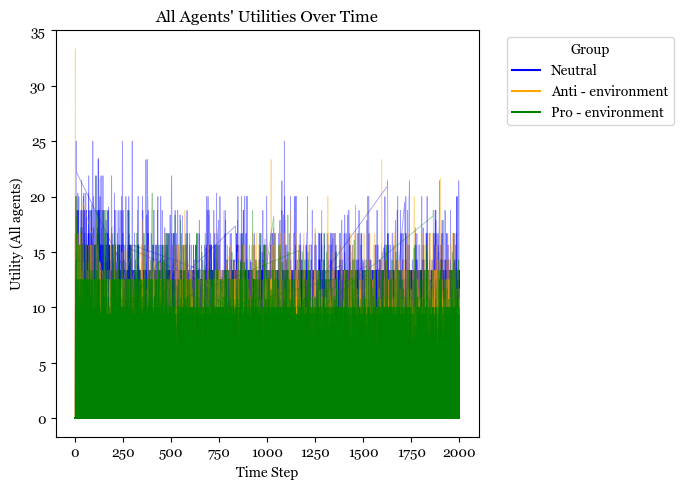

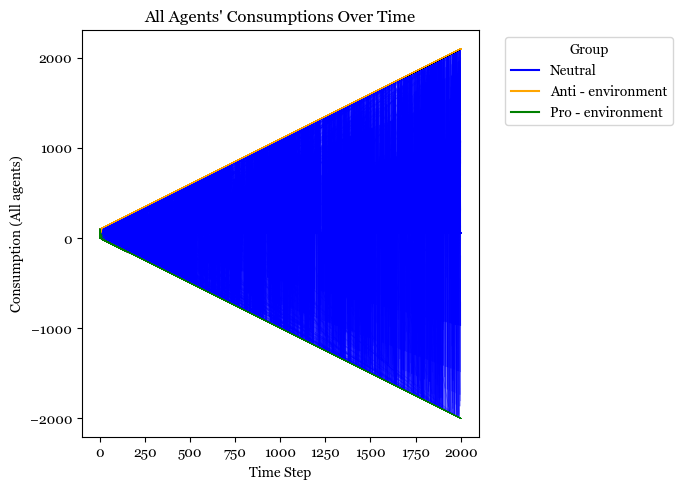

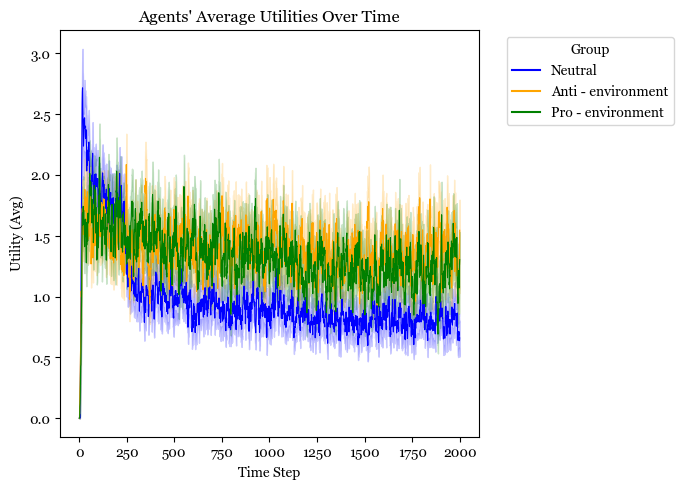

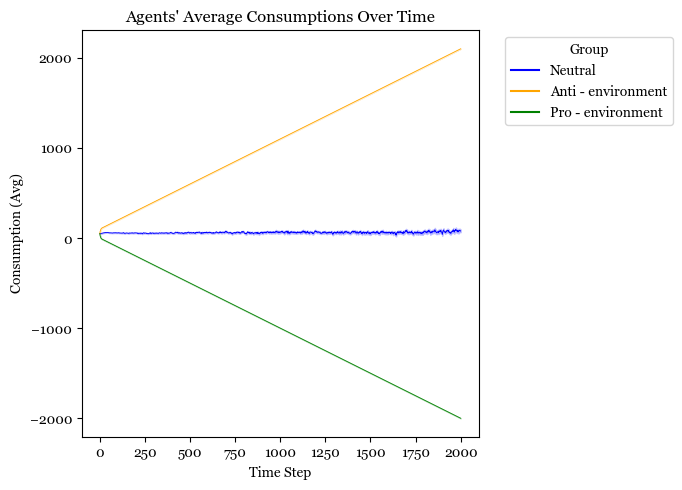

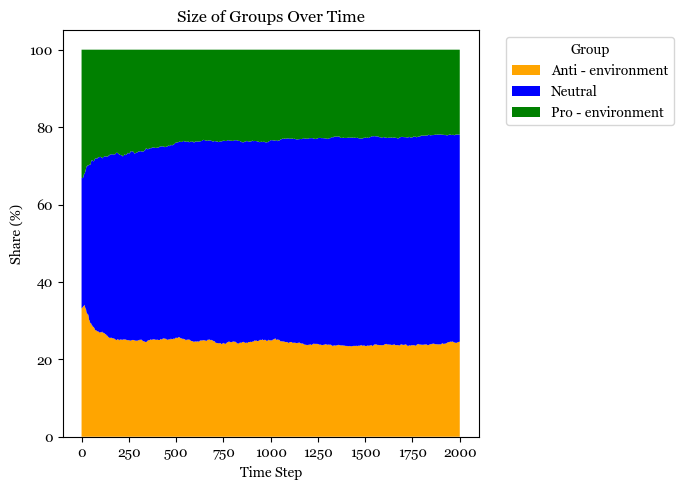

In [6]:
plot_all_agent_graphs(alternative_game_agents, color_dict, output_folder="lambda_1_2_alternative_test", show_plots=True)

In [1]:
# Batch run of the alternative model (restart before runnning)
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mesa

# Set a seed
np.random.seed(666)

# Plotting settings

from helpers import plot_all_agent_graphs
# Graphs font
plt.rcParams['font.family'] = 'Georgia'
color_dict = {
    'Anti - environment': 'orange',
    'Neutral': 'blue',
    'Pro - environment': 'green'
}

# Run
from model_statusgame import statusgame_model

params = {"seed": 666, 'N':[150, 300, 600],'lambda_s': [1, 3/4, 1/2, 1/4, 0], "status_strategy": "nontie", "memory": [10, 50, 100], "type_game": "alternative"}

results_batch = mesa.batch_run(
    statusgame_model,
    parameters=params,
    iterations=5,
    max_steps=100,
    number_processes=1,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

results_batch_df = pd.DataFrame(results_batch)
results_batch_df.to_csv("results_batch_df.csv")

  0%|          | 0/225 [00:00<?, ?it/s]

In [45]:
# Dominance vs lambda_s
results_batch_df = pd.read_csv("/Users/santiagoherreragarcia/Documents/GitHub/uniandes/enviromental_behavior_dynamics/results_batch_df.csv")
results_batch_df = results_batch_df.loc[(results_batch_df["memory"] == 10) & (results_batch_df["N"] == 600)]

grouped_iterations = results_batch_df.groupby(["lambda_s","iteration"])["group"].value_counts(normalize=True)
grouped_iterations.name = "share"
grouped_iterations = grouped_iterations.reset_index()
grouped_iterations = grouped_iterations.groupby(["lambda_s","iteration"]).agg(share = ("share","max"))
grouped_iterations = grouped_iterations.reset_index()

In [48]:
grouped_iterations

,lambda_s,iteration,share
0,0.00,0,0.340000
1,0.00,1,0.340000
2,0.00,2,0.340000
3,0.00,3,0.340000
4,0.00,4,0.340000
5,0.25,0,0.425000
6,0.25,1,0.458333
7,0.25,2,0.468333
8,0.25,3,0.448333
9,0.25,4,0.461667


<Axes: xlabel='lambda_s', ylabel='share'>

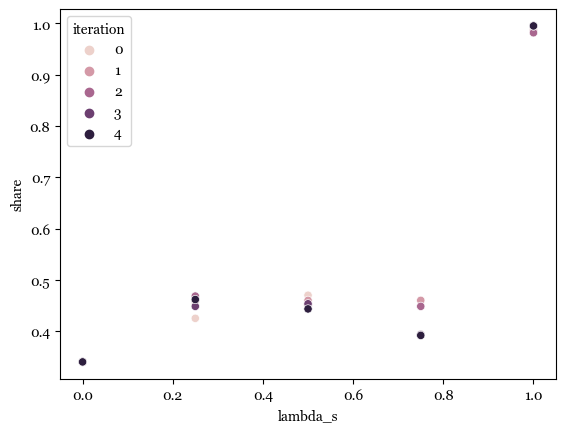

In [47]:
sns.scatterplot(grouped_iterations, x = "lambda_s", y = "share", hue = "iteration")

In [83]:
from model_statusgame import statusgame_model

In [16]:
results_batch_df.iteration.unique()

array([0, 1, 2, 3, 4])

In [17]:
results_batch_df.head()

,Unnamed: 0,RunId,iteration,Step,seed,N,lambda_s,status_strategy,memory,type_game,...,utility,belief_min,belief_median,belief_max,u_pro,u_anti,u_neutral,status_pro,status_anti,status_neutral
6750,6750,30,0,100,666,600,1.0,nontie,10,alternative,...,9.090909,-98.735184,-98.735184,-97.735184,9.090909,0.0,9.090909,9.090909,0.0,9.090909
6751,6751,30,0,100,666,600,1.0,nontie,10,alternative,...,0.000000,-98.735184,-98.735184,-98.735184,0.000000,0.0,0.000000,0.000000,0.0,0.000000
6752,6752,30,0,100,666,600,1.0,nontie,10,alternative,...,20.000000,-98.735184,-98.735184,-98.735184,20.000000,0.0,0.000000,20.000000,0.0,0.000000
6753,6753,30,0,100,666,600,1.0,nontie,10,alternative,...,0.000000,-98.735184,-98.735184,-98.735184,0.000000,0.0,0.000000,0.000000,0.0,0.000000
6754,6754,30,0,100,666,600,1.0,nontie,10,alternative,...,30.000000,-98.735184,-98.735184,-98.735184,30.000000,0.0,0.000000,30.000000,0.0,0.000000


In [49]:
testdict = {"a":1}

In [52]:
testdict[1]

KeyError: 1

In [79]:
unique_ids = [2,3,4,67,8,11]
mapping = dict(enumerate(unique_ids))
G_numeric = nx.fast_gnp_random_graph(len(unique_ids), 1/2)
G = nx.relabel_nodes(G_numeric, mapping)
G.add_edges_from([(2,3), (4,2)])
initial_edges = list(G.edges())

In [80]:
history_pairs = {}
for i, e in enumerate(initial_edges):
    history_pairs[i] = [e]   

In [81]:
history_pairs

{0: [(2, 67)],
 1: [(2, 11)],
 2: [(2, 3)],
 3: [(2, 4)],
 4: [(3, 67)],
 5: [(4, 67)],
 6: [(4, 11)],
 7: [(67, 8)],
 8: [(67, 11)]}

In [82]:
G.edges()

EdgeView([(2, 67), (2, 11), (2, 3), (2, 4), (3, 67), (4, 67), (4, 11), (67, 8), (67, 11)])

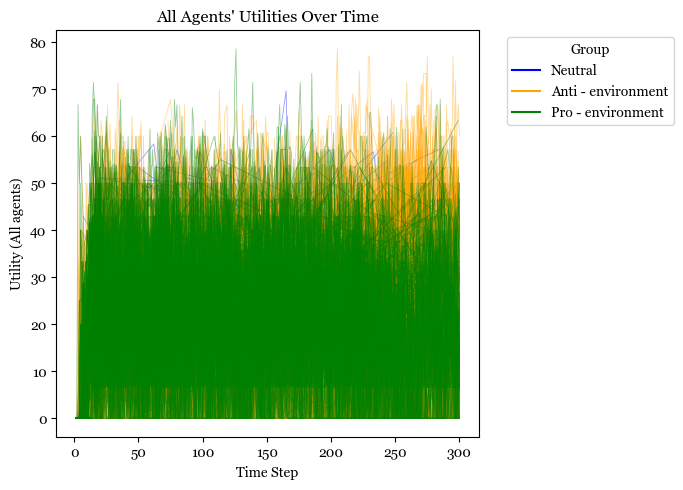

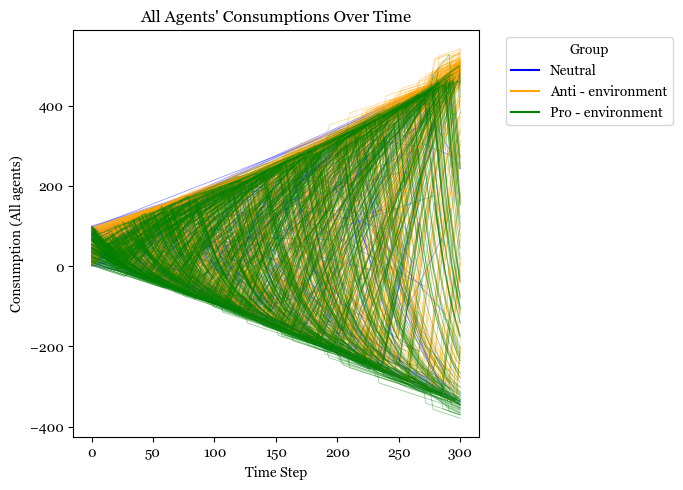

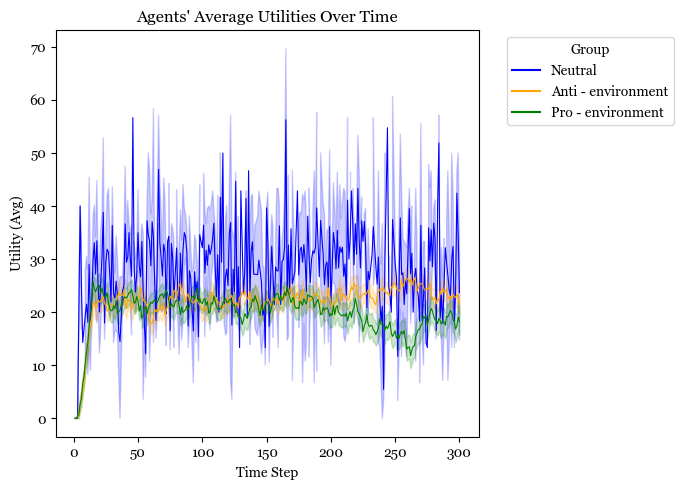

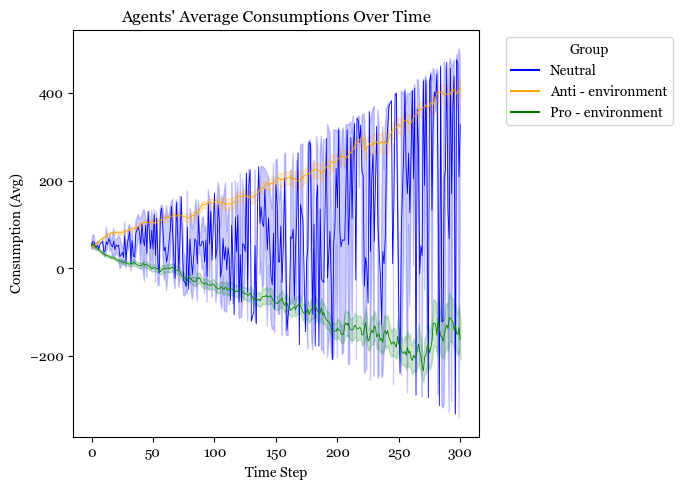

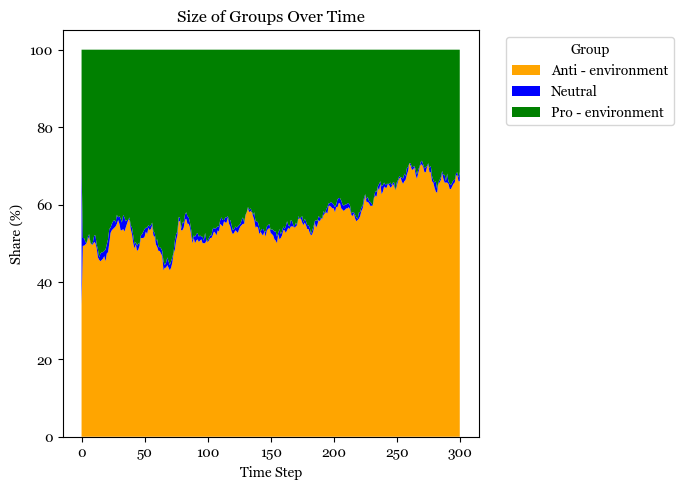

In [1]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mesa

# Set a seed
np.random.seed(666)

# Plotting settings

from helpers import plot_all_agent_graphs
# Graphs font
plt.rcParams['font.family'] = 'Georgia'
color_dict = {
    'Anti - environment': 'orange',
    'Neutral': 'blue',
    'Pro - environment': 'green'
}

from model_statusgame import statusgame_model

alternative_game = statusgame_model(N = 300, seed=666, lambda_s = 1, memory = 15, create_network=False, gamma=20)
for i in range(300):
    alternative_game.step()

# Collect data
alternative_game_model = alternative_game.datacollector.get_model_vars_dataframe() 
alternative_game_agents = alternative_game.datacollector.get_agent_vars_dataframe().reset_index()
plot_all_agent_graphs(alternative_game_agents, color_dict, output_folder="test_1_creation", show_plots=True)

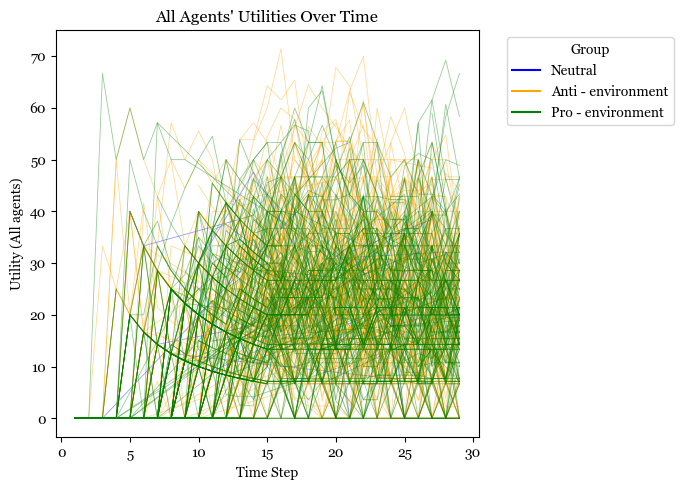

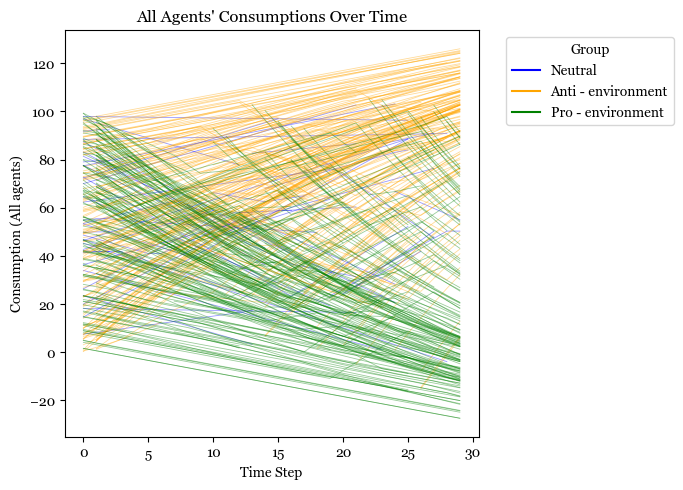

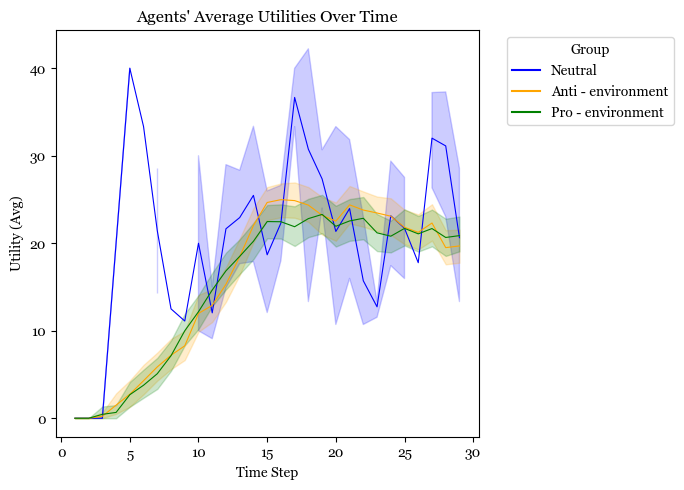

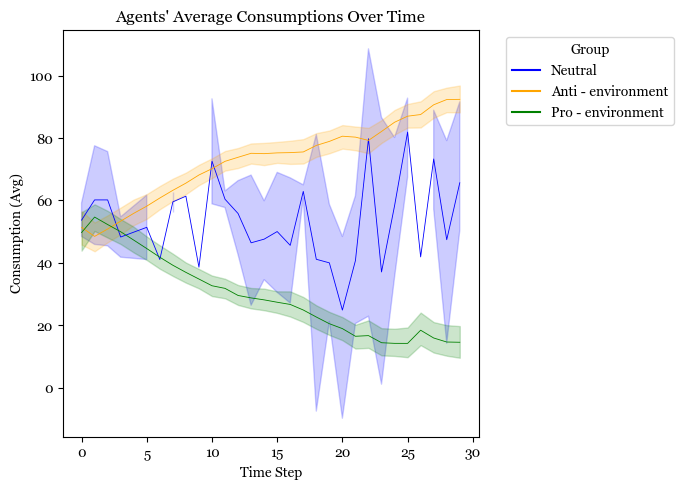

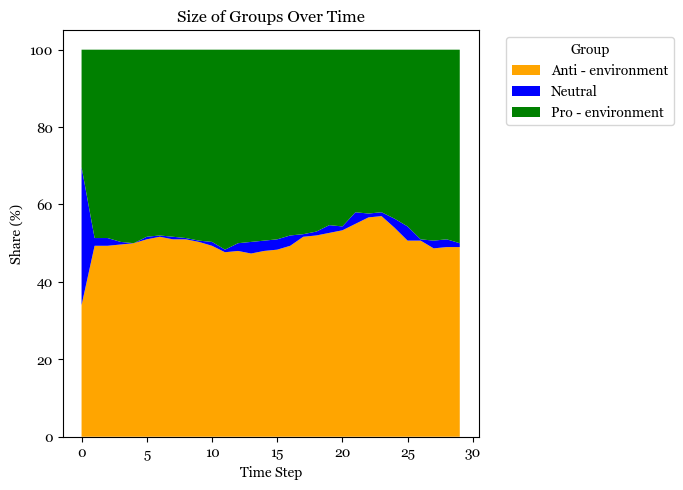

In [2]:
# Collect data
alternative_game_agents_pre200 = alternative_game_agents.loc[alternative_game_agents["Step"] < 30]
plot_all_agent_graphs(alternative_game_agents_pre200, color_dict, output_folder="test_1_creation", show_plots=True)

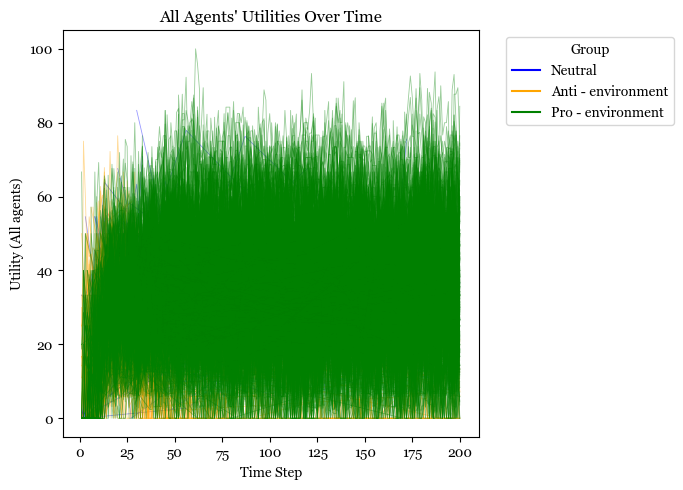

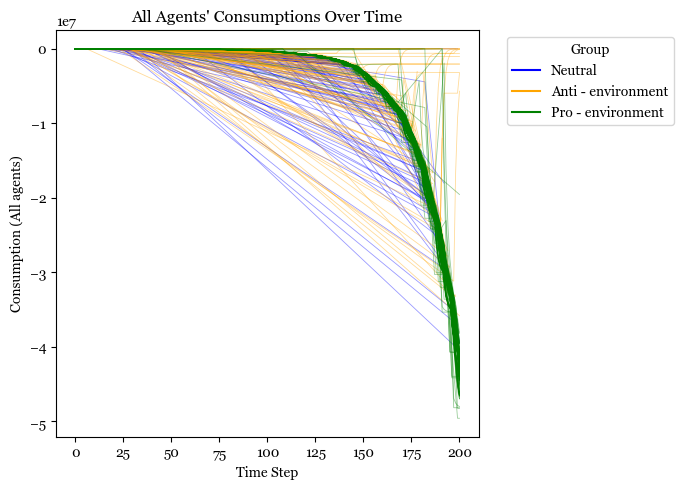

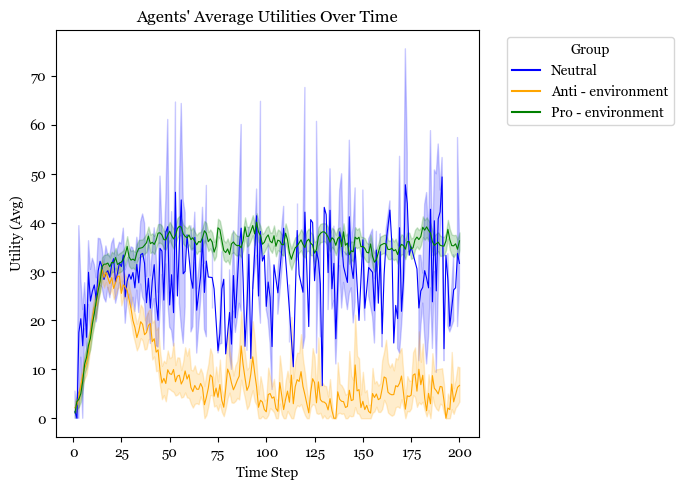

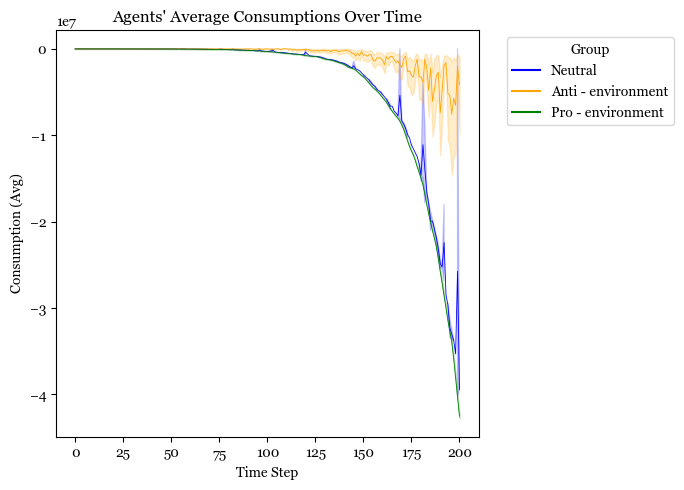

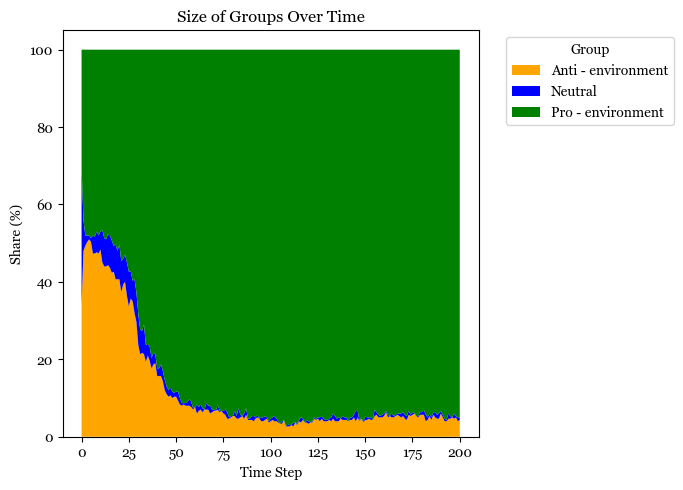

In [3]:
alternative_game = statusgame_model(N = 300, seed=666, lambda_s = 1, memory = 15, create_network=True, p = 1/100)
for i in range(200):
    alternative_game.step()

# Collect data
alternative_game_model_2 = alternative_game.datacollector.get_model_vars_dataframe() 
alternative_game_agents_2 = alternative_game.datacollector.get_agent_vars_dataframe().reset_index()
plot_all_agent_graphs(alternative_game_agents_2, color_dict, output_folder="test_1_creation", show_plots=True)

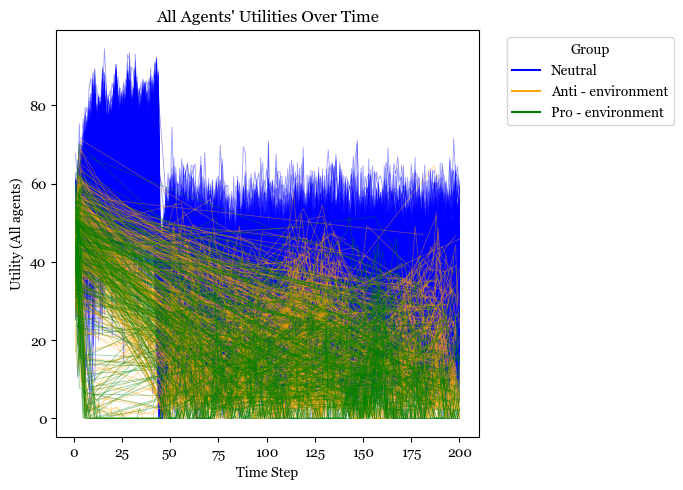

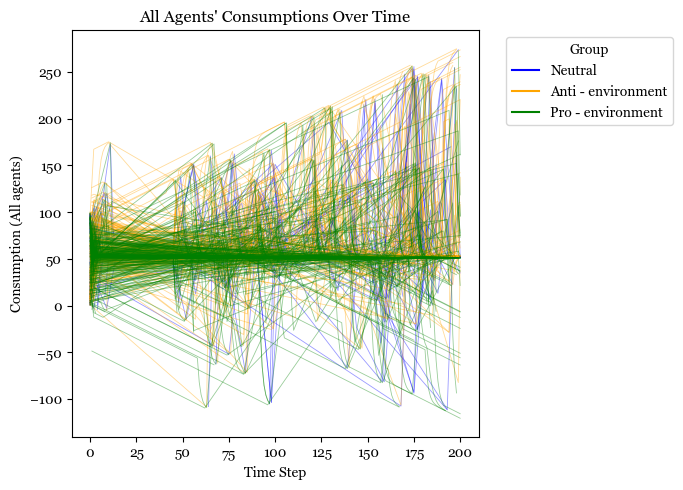

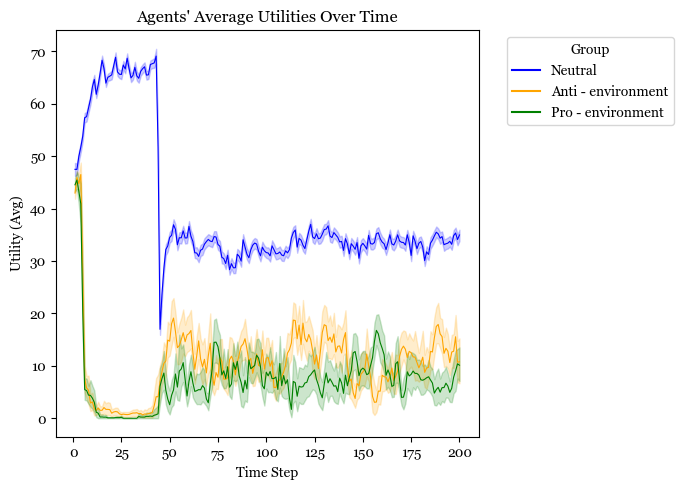

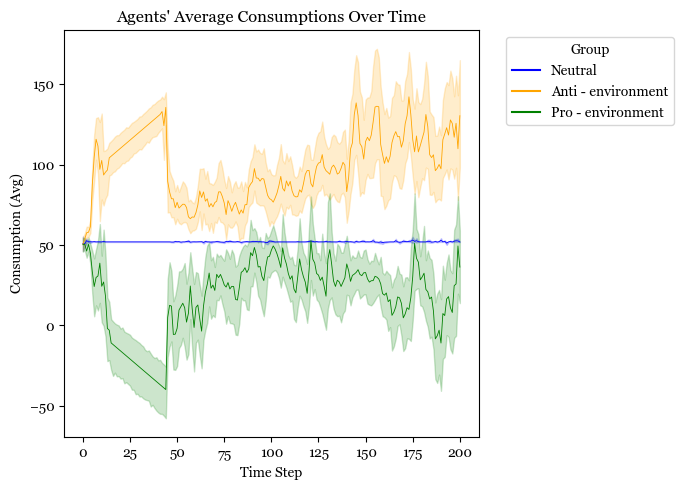

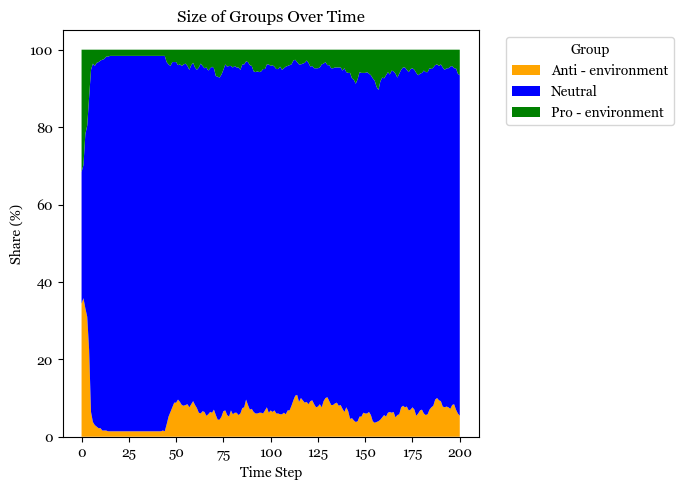

In [21]:
alternative_game = statusgame_model(N = 500, seed=10000, lambda_s = 1, memory = 15, create_network=True, p = 1/15, gamma=2)
for i in range(200):
    alternative_game.step()

# Collect data
alternative_game_model_3 = alternative_game.datacollector.get_model_vars_dataframe() 
alternative_game_agents_3 = alternative_game.datacollector.get_agent_vars_dataframe().reset_index()
plot_all_agent_graphs(alternative_game_agents_3, color_dict, output_folder="test_1_creation", show_plots=True)

In [3]:
alternative_game_agents_3.describe()

,Step,AgentID,avg_common,status,field_of_action,consumption,utility,belief_min,belief_median,belief_max,u_pro,u_anti,u_neutral,status_pro,status_anti,status_neutral
count,60300.000000,60300.000000,60000.000000,60000.000000,60000.000000,60300.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,100.000000,150.500000,3.452758,44.480673,1.574980,189.667348,53.974293,61.946153,195.492788,207.461048,23.196548,53.904409,34.209921,23.196548,53.904409,34.209921
std,58.023465,86.602777,0.621937,26.008309,1.078779,89.603478,25.140336,150.166690,79.159856,66.280737,23.952217,25.189255,20.230328,23.952217,25.189255,20.230328
min,0.000000,1.000000,1.000000,0.000000,1.000000,-190.697341,0.000000,-189.697341,20.039389,55.939088,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50.000000,75.750000,3.076923,22.755713,1.116796,133.358331,35.714286,-60.657437,138.540607,150.927191,4.292001,35.476190,19.333333,4.292001,35.476190,19.333333
50%,100.000000,150.500000,3.484848,44.000000,1.192619,201.361709,56.683686,-0.378175,203.358815,206.268916,14.079912,56.666667,33.166667,14.079912,56.666667,33.166667
75%,150.000000,225.250000,3.866667,65.555556,1.473466,262.362090,74.694264,214.075529,262.814304,266.260578,37.261905,74.691859,45.292146,37.261905,74.691859,45.292146
max,200.000000,300.000000,5.750000,100.000000,22.016963,320.234739,100.000000,317.380625,318.271809,319.234739,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [9]:
alternative_game_agents.describe()

,Step,AgentID,avg_common,status,consumption,utility,belief_min,belief_median,belief_max,u_pro,u_anti,u_neutral,status_pro,status_anti,status_neutral
count,150500.000000,150500.000000,150000.000000,150000.000000,150500.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,150.000000,250.500000,1.331929,0.399358,245.766176,14.954759,238.573130,246.286821,248.306854,0.258884,14.808724,0.360750,0.258884,14.808724,0.360750
std,86.891025,144.337758,0.215065,2.365388,94.239481,14.472727,106.861045,91.622541,87.499236,1.954548,14.503450,2.284967,1.954548,14.503450,2.284967
min,0.000000,1.000000,1.000000,0.000000,-35.609016,0.000000,-35.609016,-18.609016,4.645372,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,75.000000,125.750000,1.142857,0.000000,174.274137,0.000000,173.274137,174.024137,174.024137,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,150.000000,250.500000,1.285714,0.000000,249.274137,13.333333,248.774137,248.774137,248.774137,0.000000,13.333333,0.000000,0.000000,13.333333,0.000000
75%,225.000000,375.250000,1.428571,0.000000,324.274137,25.000000,323.524137,323.524137,323.524137,0.000000,23.076923,0.000000,0.000000,23.076923,0.000000
max,300.000000,500.000000,2.733333,66.666667,399.274137,92.307692,398.274137,398.274137,398.274137,55.555556,92.307692,66.666667,55.555556,92.307692,66.666667


In [6]:
alternative_game_agents_2.describe()

,Step,AgentID,avg_common,status,consumption,utility,belief_min,belief_median,belief_max,u_pro,u_anti,u_neutral,status_pro,status_anti,status_neutral
count,100500.000000,100500.000000,100000.000000,100000.000000,100500.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,100.000000,250.500000,1.637723,0.997311,195.836039,26.196000,188.318676,196.540281,199.213707,0.650726,25.888057,0.929341,0.650726,25.888057,0.929341
std,58.023273,144.337997,0.288337,4.010518,67.140179,18.938690,80.517608,63.862171,58.017438,3.392209,19.116073,3.925315,3.392209,19.116073,3.925315
min,0.000000,1.000000,1.000000,0.000000,-20.753109,0.000000,-20.753109,-14.753109,5.294371,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50.000000,125.750000,1.444444,0.000000,149.858960,10.526316,148.858960,149.608960,149.608960,0.000000,10.000000,0.000000,0.000000,10.000000,0.000000
50%,100.000000,250.500000,1.631579,0.000000,199.858960,25.000000,198.858960,199.358960,199.358960,0.000000,23.809524,0.000000,0.000000,23.809524,0.000000
75%,150.000000,375.250000,1.823529,0.000000,249.858960,40.000000,248.858960,249.108960,249.108960,0.000000,40.000000,0.000000,0.000000,40.000000,0.000000
max,200.000000,500.000000,3.086957,66.666667,299.858960,95.000000,298.858960,298.858960,298.858960,66.666667,95.000000,60.526316,66.666667,95.000000,60.526316


In [7]:
alternative_game_agents_3.describe()

,Step,AgentID,avg_common,status,consumption,utility,belief_min,belief_median,belief_max,u_pro,u_anti,u_neutral,status_pro,status_anti,status_neutral
count,100500.000000,100500.000000,100000.000000,100000.000000,100500.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,100.000000,250.500000,3.821272,5.865131,48.536500,6.635132,47.217704,48.582651,49.736170,0.514783,0.413844,6.588066,0.514783,0.413844,6.588066
std,58.023273,144.337997,0.615330,15.561569,4.804201,17.332225,8.174076,1.012445,7.657283,3.611368,3.204224,17.273754,3.611368,3.204224,17.273754
min,0.000000,1.000000,1.133333,0.000000,-4.987335,0.000000,-4.987335,-1.087635,48.586146,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50.000000,125.750000,3.444444,0.000000,48.586146,0.000000,48.586146,48.586146,48.586146,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,100.000000,250.500000,3.833333,0.000000,48.586146,0.000000,48.586146,48.586146,48.586146,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,150.000000,375.250000,4.230769,0.000000,48.586146,0.000000,48.586146,48.586146,48.586146,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,200.000000,500.000000,6.090909,87.916667,103.914264,88.844156,48.586146,101.473154,103.914264,59.259259,63.043478,88.844156,59.259259,63.043478,88.844156


In [ ]:
zero_step = alternative_game_agents.loc[alternative_game_agents["Step"] == 0, ["AgentID", "group"]]
group_dict = pd.Series(zero_step['group'].values, index=zero_step['AgentID']).to_dict()
g = alternative_game_model["network"][0]
nx.set_node_attributes(g, group_dict, 'group')
nx.write_gexf(g,"test.gexf")